<a href="https://colab.research.google.com/github/PhyloGrok/MolGraphs/blob/master/Network2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.2 MB/s eta 0:00:00


Import the SUBSET.csv into a bipartite network.

In [3]:
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite

# 1. Load your adjacency list file
# Change 'interactions.csv' to your filename. Use sep='\t' if it is a TSV file.
df = pd.read_csv('Adjacency_Filtered.csv')

# 2. Extract unique lists of nodes for each bipartite set
# Assumes your columns are named 'miRNA' and 'mRNA'
mirnas = df['miRNA'].unique()
mrnas = df['Gene'].unique()

# 3. Initialize an empty graph
B = nx.Graph()

# 4. Add nodes with their respective bipartite attribute (0 or 1)
B.add_nodes_from(mirnas, bipartite=0)
B.add_nodes_from(mrnas, bipartite=1)

# 5. Populate edges directly from the DataFrame rows
# This loops through each row and adds an edge between the miRNA and mRNA
edges = list(df.itertuples(index=False, name=None))
B.add_edges_from(edges)

# 6. Verify the import worked correctly
print(f"Graph is bipartite: {bipartite.is_bipartite(B)}")
print(f"Total nodes: {B.number_of_nodes()} ({len(mirnas)} miRNAs, {len(mrnas)} mRNAs)")
print(f"Total interactions: {B.number_of_edges()}")

Graph is bipartite: True
Total nodes: 483 (296 miRNAs, 187 mRNAs)
Total interactions: 1913


node attribution ONLY MIR155

In [5]:
import pandas as pd
import networkx as nx
from pyvis.network import Network

# Define your exact experimental condition column
target_condition = 'miR155'

# Load clean pre-filtered mRNA file
mrna_df = pd.read_csv('nanostring_mrna.csv')
# Convert the target_condition column to numeric, coercing errors to NaN
mrna_exp_dict = pd.Series(pd.to_numeric(mrna_df[target_condition], errors='coerce').values, index=mrna_df['ProbeID']).to_dict()

# Load clean pre-filtered miRNA file
# Original code read header as data, which caused 'miR155' string in data. Correct by dropping first row.
mirna_df = pd.read_csv('nanostring_mirna.csv', header=None, names=['ProbeID', 'Accession', 'Analyte', 'Control', 'cel67', 'miR142', 'miR155', 'miR18b', 'miR890'])
mirna_df = mirna_df.drop(0).reset_index(drop=True) # Drop the header row that was read as data
# Convert the target_condition column to numeric, coercing errors to NaN
mirna_exp_dict = pd.Series(pd.to_numeric(mirna_df[target_condition], errors='coerce').values, index=mirna_df['ProbeID']).to_dict()

# Combine both dictionary structures into one tracking database
all_raw_expressions = {**mrna_exp_dict, **mirna_exp_dict}

# Push clean values onto the loaded NetworkX graph (B)
nx.set_node_attributes(B, all_raw_expressions, name='raw_expression')

net = Network(notebook=True, cdn_resources='in_line', height="600px", width="100%", bgcolor="#222222", font_color="white")
net.from_nx(B)

# Calculate independent maximums from the graph layers to preserve visual parity

# Filter out NaN values before calculating max, as NaN cannot be compared.
max_mirna_val = max([val for val in [B.nodes[n].get('raw_expression', 1) for n, attr in B.nodes(data=True) if attr.get('bipartite') == 0] if pd.notna(val)] or [1])
max_mrna_val = max([val for val in [B.nodes[n].get('raw_expression', 1) for n, attr in B.nodes(data=True) if attr.get('bipartite') == 1] if pd.notna(val)] or [1])

for node in net.nodes:
    raw_exp = node.get('raw_expression', 0)

    # Handle potential NaN values that might result from 'coerce' during to_numeric
    if pd.isna(raw_exp):
        raw_exp = 0 # Default to 0 for NaN values

    # Scale each molecule type relative to its own layer maximum (Base size 10 to Max size 40)
    if node['bipartite'] == 0:
        node['color'] = '#FF6B6B'  # Salmon for miRNA
        node['shape'] = 'diamond'
        node['size'] = 5 + ((raw_exp / max_mirna_val) * 35)
    else:
        node['color'] = '#4D96FF'  # Sky Blue for mRNA
        node['shape'] = 'dot'
        node['size'] = 5 + ((raw_exp / max_mrna_val) * 35)

    # Tooltip tracking windows reveal actual absolute numbers on hover
    node['title'] = f"ID: {node['id']}<br>Raw Expression: {raw_exp:.2f}"

#toggle physics for a moving visualization
net.toggle_physics(True)
net.show("mirna_mrna_network_5_35.html")

mirna_mrna_network_5_35.html


LOOP TRIAL FOR CEL67, 142, 155, 18B, 890 **(add log)**, y or x projections, add differentiating colors for plotly visualizations for each? how many miRNAs are regulating, legend centrality (where in the network it is), use the scaling after the log?

find equivalent for network entrality metrics under readme

In [6]:
import pandas as pd
import networkx as nx
from pyvis.network import Network

target_conditions_list = ['cel67', 'miR142', 'miR155', 'miR18b', 'miR890']

for target_condition in target_conditions_list:
    print(f"Processing for condition: {target_condition}")

    mrna_df = pd.read_csv('nanostring_mrna.csv')

    mrna_exp_dict = pd.Series(pd.to_numeric(mrna_df[target_condition], errors='coerce').values, index=mrna_df['ProbeID']).to_dict()

    mirna_df = pd.read_csv('nanostring_mirna.csv', header=None, names=['ProbeID', 'Accession', 'Analyte', 'Control', 'cel67', 'miR142', 'miR155', 'miR18b', 'miR890'])
    mirna_df = mirna_df.drop(0).reset_index(drop=True)

    mirna_exp_dict = pd.Series(pd.to_numeric(mirna_df[target_condition], errors='coerce').values, index=mirna_df['ProbeID']).to_dict()


    all_raw_expressions = {**mrna_exp_dict, **mirna_exp_dict}

    nx.set_node_attributes(B, all_raw_expressions, name='raw_expression')

    net = Network(notebook=True, cdn_resources='in_line', height="600px", width="100%", bgcolor="#222222", font_color="white")
    net.from_nx(B)


    max_mirna_val = max([val for val in [B.nodes[n].get('raw_expression', 1) for n, attr in B.nodes(data=True) if attr.get('bipartite') == 0] if pd.notna(val)] or [1])
    max_mrna_val = max([val for val in [B.nodes[n].get('raw_expression', 1) for n, attr in B.nodes(data=True) if attr.get('bipartite') == 1] if pd.notna(val)] or [1])

    for node in net.nodes:
        raw_exp = node.get('raw_expression', 0)

        if pd.isna(raw_exp):
            raw_exp = 0

        # Scale each molecule type relative to its own layer maximum (Base size 10 to Max size 40)
        if node['bipartite'] == 0:
            node['color'] = '#FF6B6B'  # Salmon for miRNA
            node['shape'] = 'diamond'
            node['size'] = 5 + ((raw_exp / max_mirna_val) * 35)
        else:
            node['color'] = '#4D96FF'  # Sky Blue for mRNA
            node['shape'] = 'dot'
            node['size'] = 5 + ((raw_exp / max_mrna_val) * 35)

        # Tooltip tracking windows reveal actual absolute numbers on hover
        node['title'] = f"ID: {node['id']}<br>Raw Expression: {raw_exp:.2f}"

    #toggle physics for a moving visualization
    net.toggle_physics(True)
    net.show(f"mirna_mrna_network_{target_condition}.html")


Processing for condition: cel67
mirna_mrna_network_cel67.html
Processing for condition: miR142
mirna_mrna_network_miR142.html
Processing for condition: miR155
mirna_mrna_network_miR155.html
Processing for condition: miR18b
mirna_mrna_network_miR18b.html
Processing for condition: miR890
mirna_mrna_network_miR890.html


PLOTLY LOOP TRIAL,LOG TRANSFORM, WITH LABELS

In [7]:
#importing
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import numpy as np

#loop to iterate through all conditions + control cel67
target_conditions_list = ['cel67', 'miR142', 'miR155', 'miR18b', 'miR890']

for target_condition in target_conditions_list:
    print(f"Processing for condition: {target_condition}")

#converting values to numbers to map to corresponding probeid, forcing errors into Nan, making expression dictionary (mrna)
    mrna_df = pd.read_csv('nanostring_mrna.csv')
    mrna_exp_dict = pd.Series(pd.to_numeric(mrna_df[target_condition], errors='coerce').values, index=mrna_df['ProbeID']).to_dict()

#dropping header row and making an expression dictionary (mirna)
    mirna_df = pd.read_csv('nanostring_mirna.csv', header=None, names=['ProbeID', 'Accession', 'Analyte', 'Control', 'cel67', 'miR142', 'miR155', 'miR18b', 'miR890'])
    mirna_df = mirna_df.drop(0).reset_index(drop=True)
    mirna_exp_dict = pd.Series(pd.to_numeric(mirna_df[target_condition], errors='coerce').values, index=mirna_df['ProbeID']).to_dict()

#combinging the mirna and mrna expression dictionaries into one --> node attribute called raw expression
    all_raw_expressions = {**mrna_exp_dict, **mirna_exp_dict}
    nx.set_node_attributes(B, all_raw_expressions, name='raw_expression')


#making a 2d plot for every node
    pos = nx.spring_layout(B, k=0.5, iterations=50)

    edge_x = []
    edge_y = []
    for edge in B.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.append(x0)
        edge_x.append(x1)
        edge_x.append(None)
        edge_y.append(y0)
        edge_y.append(y1)
        edge_y.append(None)

#grey line connecting nodes and turning off hover***
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#aba6a6'),
        hoverinfo='none',
        mode='lines')
# making lists to hold node configurations to normalize node sizes
#finding the highest expressions for mirna (0) and mrna (1)
    node_x = []
    node_y = []
    node_sizes = []
    node_colors = []
    node_text = []
    node_labels = []

    max_mirna_val = max([val for val in [B.nodes[n].get('raw_expression', 1) for n, attr in B.nodes(data=True) if attr.get('bipartite') == 0] if pd.notna(val)] or [1])
    max_mrna_val = max([val for val in [B.nodes[n].get('raw_expression', 1) for n, attr in B.nodes(data=True) if attr.get('bipartite') == 1] if pd.notna(val)] or [1])

#making 0s (mirnas) red and 1s (mrnas) blue
#using np.log1p to handle expression values equal to 0 and scale expression
    for node_id in B.nodes():
        x, y = pos[node_id]
        node_x.append(x)
        node_y.append(y)

        attr = B.nodes[node_id]
        raw_exp = attr.get('raw_expression', 0)

        if pd.isna(raw_exp):
            raw_exp = 0

        if attr['bipartite'] == 0:
            node_colors.append('#FF6B6B')
            size = 5 + ((np.log1p(raw_exp) / np.log1p(max_mirna_val)) * 35)
        else:
            node_colors.append('#4D96FF')
            size = 5 + ((np.log1p(raw_exp) / np.log1p(max_mrna_val)) * 35)

        node_sizes.append(size)
        node_text.append(f"ID: {node_id}<br>Raw Expression: {raw_exp:.2f}")
        node_labels.append(str(node_id))
#turning on hover and formatting nodes with centered labels in white
#removing axes
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers + text',
        text=node_labels,
        textposition='middle center',
        hoverinfo='text',
        hovertext=node_text,
        textfont=dict(size = 5, color = 'white'),
        marker=dict(
            showscale=False,
            color=node_colors,
            size=node_sizes,
            line_width=1))

    fig = go.Figure(data=[edge_trace, node_trace],
                 layout=go.Layout(
                    title=f'Network Visualization for {target_condition} (log transform)',
                    titlefont_size=16,
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=20,l=5,r=5,t=40),
                    annotations=[ dict(
                        text="Python Plotly Network",
                        showarrow=False,
                        xref="paper", yref="paper",
                        x=0.005, y=-0.002 ) ],
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)))
    fig.show()


Processing for condition: cel67


Processing for condition: miR142


Processing for condition: miR155


Processing for condition: miR18b


Processing for condition: miR890


eigen centrality and closeness * unfinished

Head of centrality DataFrame:


,Type,deg,bet,clos,eig
ProbeID,,,,,
hsa-let-7a-5p,miRNA,20,0.019779,0.370549,0.104814
hsa-let-7b-5p,miRNA,31,0.047142,0.392453,0.136343
hsa-let-7c-5p,miRNA,15,0.012970,0.359405,0.085413
hsa-miR-100-5p,miRNA,6,0.001724,0.304077,0.022004
hsa-miR-1200,miRNA,4,0.000828,0.298382,0.022972



Summary of centrality DataFrame:


,deg,bet,clos,eig
count,483.000000,483.000000,483.000000,4.830000e+02
mean,7.921325,0.004955,0.295711,3.009590e-02
std,8.501039,0.010080,0.040285,3.416206e-02
min,1.000000,0.000000,0.002075,5.084940e-74
25%,2.000000,0.000133,0.271365,7.627152e-03
50%,5.000000,0.001046,0.294340,1.726908e-02
75%,11.000000,0.005137,0.323744,4.092585e-02
max,57.000000,0.087277,0.398009,2.136790e-01


<function matplotlib.pyplot.show(close=None, block=None)>

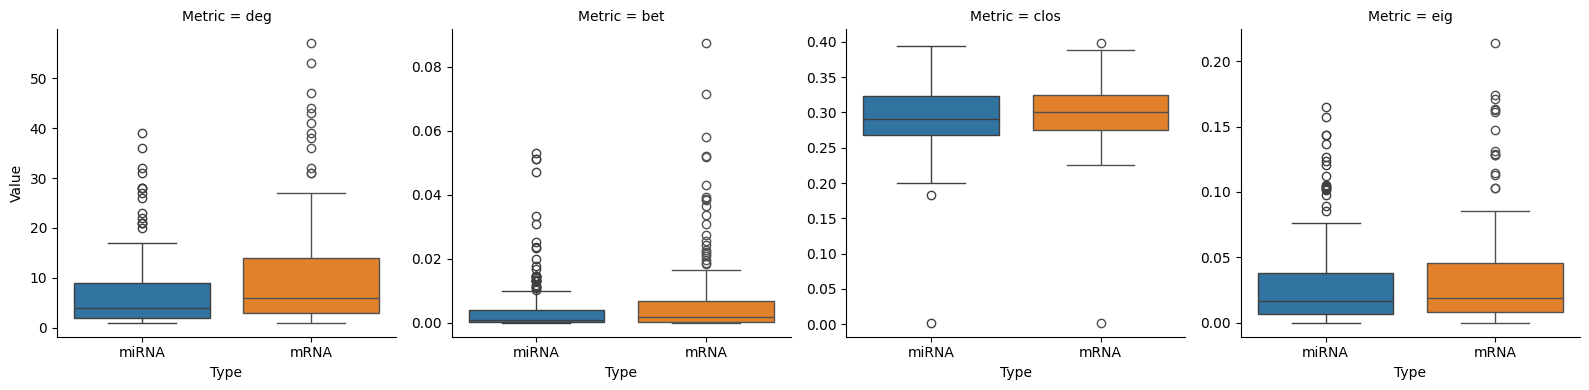

In [8]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

node_data = []
for node_id, attributes in B.nodes(data=True):
    node_type = 'miRNA' if attributes.get('bipartite') == 0 else 'mRNA'
    node_data.append({'ProbeID': node_id, 'Type': node_type})

types_df = pd.DataFrame(node_data).set_index('ProbeID')


deg_dict = dict(B.degree())
bet_dict = nx.betweenness_centrality(B)
close_dict = nx.closeness_centrality(B)
eig_dict = nx.eigenvector_centrality(B)


# dataframes
deg_df = pd.Series(deg_dict, name='deg').to_frame()
bet_df = pd.Series(bet_dict, name='bet').to_frame()
clos_df = pd.Series(close_dict, name='clos').to_frame()
eig_df = pd.Series(eig_dict, name='eig').to_frame()

# Combine all into a single dataframe
cent_df = types_df.join([deg_df, bet_df, clos_df, eig_df])

print("Head of centrality DataFrame:")
display(cent_df.head())

print("\nSummary of centrality DataFrame:")
summary_df = cent_df.describe()
display(summary_df)

# box and whisker plot

melted_df = cent_df.melt(id_vars=['Type'], value_vars=['deg', 'bet', 'clos', 'eig'], var_name='Metric', value_name='Value')

g = sns.FacetGrid(melted_df, col = "Metric", hue = "Type", sharey = False, height = 4, aspect = 1)
g.map_dataframe(sns.boxplot, x = "Type", y = "Value")

plt.show


degree: number of direct connects the mirna has
- higher = more interactions

betweenness: how often the mirna exists between two nodes
- higher = bridges often --> controls information flow

closeness: how close a node is to another node
- higher = more information spread quickly from this mirna to the rest of the network

eigen = how well connected a node's neighbors are
- higher = mirna is connected to more important nodes
_________________________
483 unique mirnas analyzed
- average mirna has 7.9 connections
(skewed, 50% have 5 or fewer while one has 57)

------------------

degree scale bigger than rest


scatter plot visualization

mrna
- y axis: degree
- x axis = mirna targets

mirna
- y axis: degree
- x axis = mrna targets

get the list of genes that are the most connected to the network --> most central


expression (y) vs degree (x), downward slope?
for each of the 5 treatments

degree delta vs expression delta
- where topological changes correlate with shifts in expression
- one graph for mirna and one graph for mrna --> 10 total

using the data frame existing for degree (even though it has betweeness, closeness, eigen) and just add degree

add a line of best fit
- higher degree should have lower levels of expression, ideally


Generating plots for condition: cel67


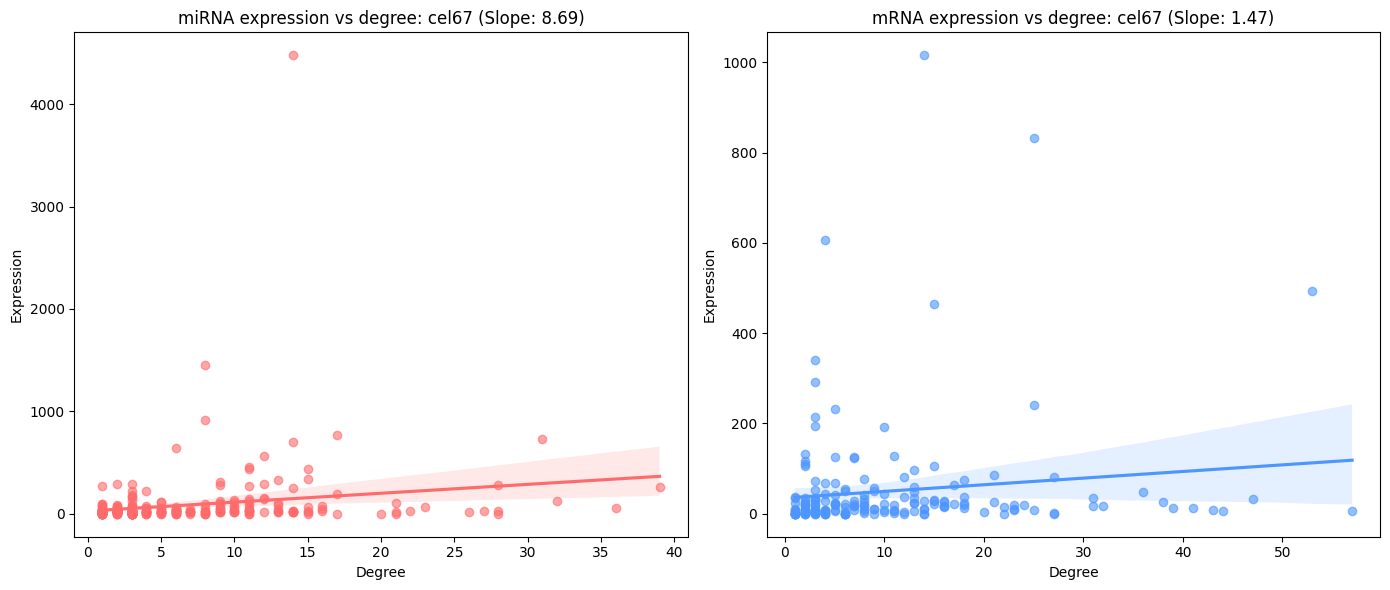

Generating plots for condition: miR142


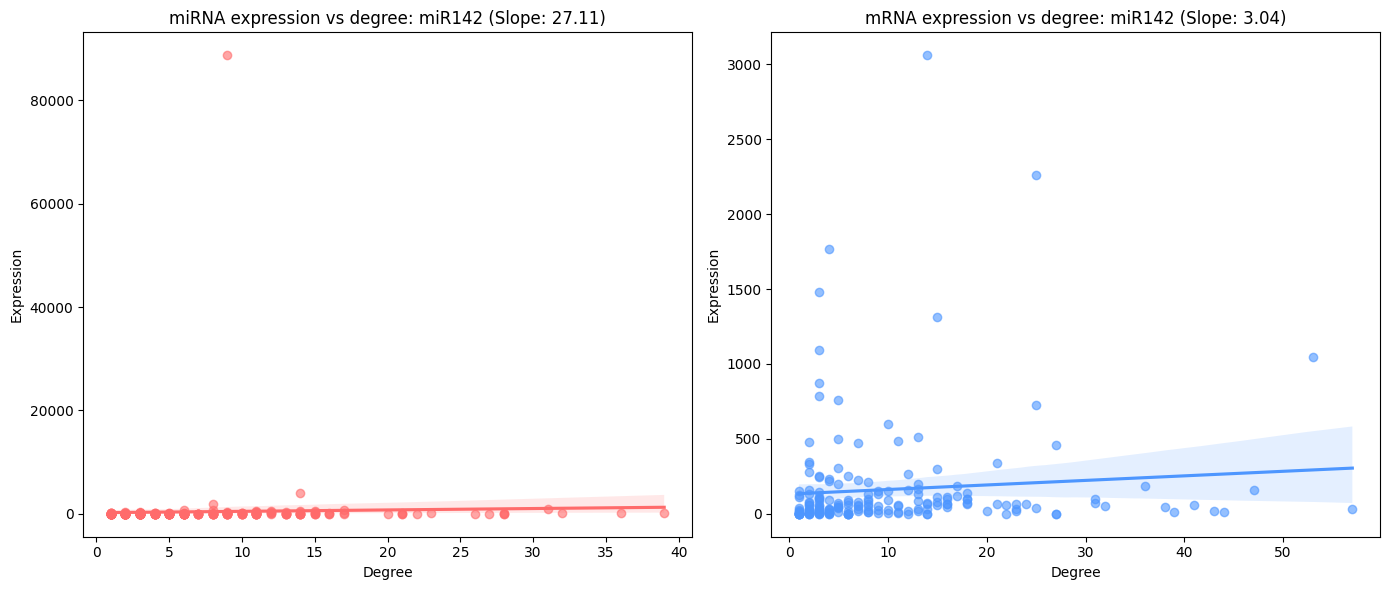

Generating plots for condition: miR155


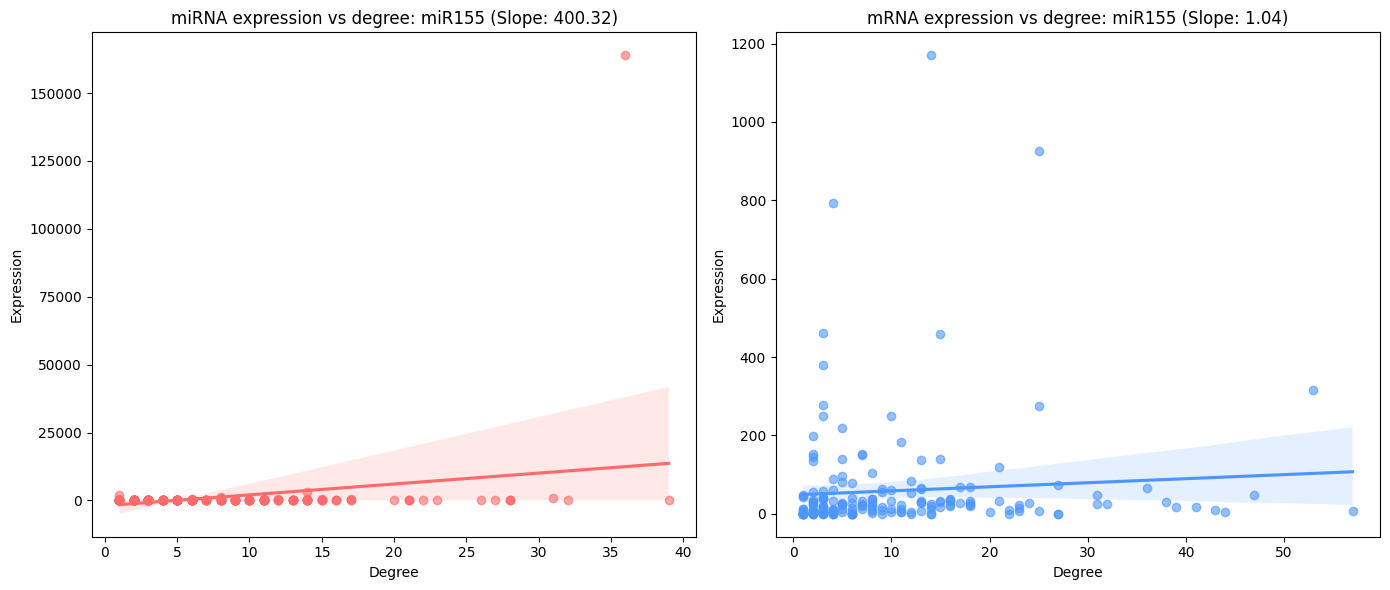

Generating plots for condition: miR18b


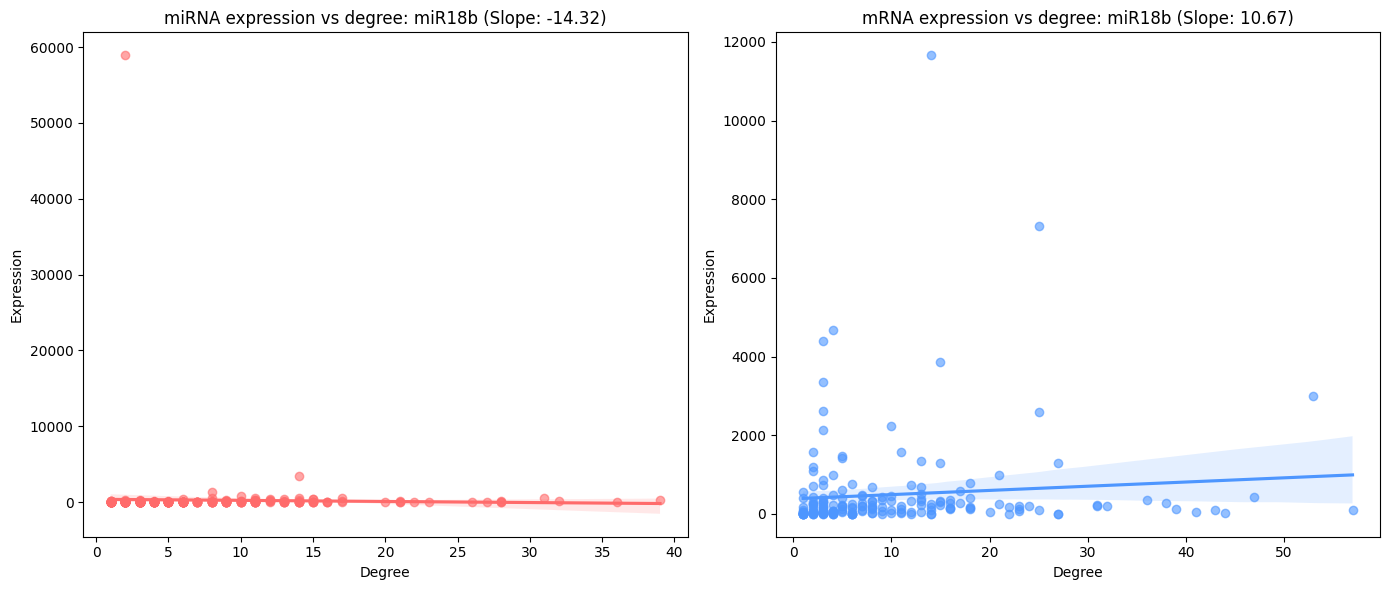

Generating plots for condition: miR890


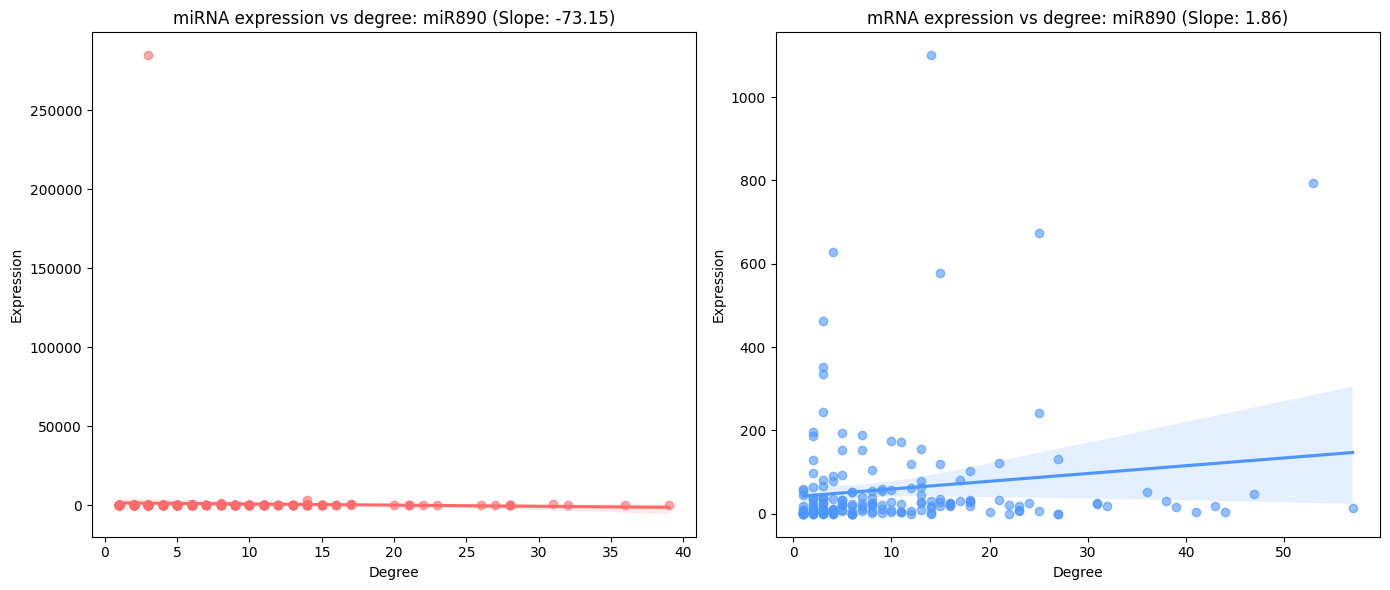

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import linregress

target_conditions_list = ['cel67', 'miR142', 'miR155', 'miR18b', 'miR890']

for target_condition in target_conditions_list:
    print(f"Generating plots for condition: {target_condition}")

    mrna_df = pd.read_csv('nanostring_mrna.csv')
    mrna_exp_dict = pd.Series(pd.to_numeric(mrna_df[target_condition], errors='coerce').values, index=mrna_df['ProbeID']).to_dict()


    mirna_df = pd.read_csv('nanostring_mirna.csv', header=None, names=['ProbeID', 'Accession', 'Analyte', 'Control', 'cel67', 'miR142', 'miR155', 'miR18b', 'miR890'])
    mirna_df = mirna_df.drop(0).reset_index(drop=True)
    mirna_exp_dict = pd.Series(pd.to_numeric(mirna_df[target_condition], errors='coerce').values, index=mirna_df['ProbeID']).to_dict()


    all_raw_expressions = {**mrna_exp_dict, **mirna_exp_dict}
    nx.set_node_attributes(B, all_raw_expressions, name='raw_expression')


    deg_dict = dict(B.degree())

    mirna_plot_data = []
    mrna_plot_data = []

    for node_id, attributes in B.nodes(data=True):
        raw_exp = attributes.get('raw_expression')
        if pd.isna(raw_exp):
            raw_exp = 0

        degree = deg_dict.get(node_id, 0)

        if attributes.get('bipartite') == 0:
            mirna_plot_data.append({'ID': node_id, 'Expression': raw_exp, 'Degree': degree})
        else:
            mrna_plot_data.append({'ID': node_id, 'Expression': raw_exp, 'Degree': degree})

    mirna_plot_df = pd.DataFrame(mirna_plot_data)
    mrna_plot_df = pd.DataFrame(mrna_plot_data)

    plt.figure(figsize=(14, 6))


    plt.subplot(1, 2, 1)
    if not mirna_plot_df.empty:
        sns.regplot(x='Degree', y='Expression', data=mirna_plot_df, scatter_kws={'alpha':0.6, 'color':'#FF6B6B'}, line_kws={'color':'#FF6B6B'})
        mirna_slope = 0.0
        if len(mirna_plot_df['Degree'].unique()) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(mirna_plot_df['Degree'], mirna_plot_df['Expression'])
            mirna_slope = slope
        plt.title(f'miRNA expression vs degree: {target_condition} (Slope: {mirna_slope:.2f})')
        plt.xlabel('Degree')
        plt.ylabel('Expression')

    plt.subplot(1, 2, 2)
    if not mrna_plot_df.empty:
        sns.regplot(x='Degree', y='Expression', data=mrna_plot_df, scatter_kws={'alpha':0.6, 'color':'#4D96FF'}, line_kws={'color':'#4D96FF'})
        mrna_slope = 0.0
        if len(mrna_plot_df['Degree'].unique()) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(mrna_plot_df['Degree'], mrna_plot_df['Expression'])
            mrna_slope = slope
        plt.title(f'mRNA expression vs degree: {target_condition} (Slope: {mrna_slope:.2f})')
        plt.xlabel('Degree')
        plt.ylabel('Expression')


    plt.tight_layout()
    plt.show()

formatting row 1: mrna row 2: microrna, columns: target conditions


In [10]:
import pandas as pd
import numpy as np
import networkx as nx
from scipy.stats import linregress
import plotly.graph_objects as go

target_conditions_list = ['cel67', 'miR142', 'miR155', 'miR18b', 'miR890']

for target_condition in target_conditions_list:
    print(f"Generating plots for condition: {target_condition}")

    mrna_df = pd.read_csv('nanostring_mrna.csv')
    mrna_exp_dict = pd.Series(pd.to_numeric(mrna_df[target_condition], errors='coerce').values, index=mrna_df['ProbeID']).to_dict()


    mirna_df = pd.read_csv('nanostring_mirna.csv', header=None, names=['ProbeID', 'Accession', 'Analyte', 'Control', 'cel67', 'miR142', 'miR155', 'miR18b', 'miR890'])
    mirna_df = mirna_df.drop(0).reset_index(drop=True)
    mirna_exp_dict = pd.Series(pd.to_numeric(mirna_df[target_condition], errors='coerce').values, index=mirna_df['ProbeID']).to_dict()


    all_raw_expressions = {**mrna_exp_dict, **mirna_exp_dict}
    nx.set_node_attributes(B, all_raw_expressions, name='raw_expression')


    deg_dict = dict(B.degree())

    mirna_plot_data = []
    mrna_plot_data = []

    for node_id, attributes in B.nodes(data=True):
        raw_exp = attributes.get('raw_expression')
        if pd.isna(raw_exp):
            raw_exp = 0

        degree = deg_dict.get(node_id, 0)

        if attributes.get('bipartite') == 0:
            mirna_plot_data.append({'ID': node_id, 'Expression': raw_exp, 'Degree': degree})
        else:
            mrna_plot_data.append({'ID': node_id, 'Expression': raw_exp, 'Degree': degree})

    mirna_plot_df = pd.DataFrame(mirna_plot_data)
    mrna_plot_df = pd.DataFrame(mrna_plot_data)

    if not mirna_plot_df.empty:
        mirna_slope = 0.0
        mirna_intercept = 0.0
        if len(mirna_plot_df['Degree'].unique()) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(mirna_plot_df['Degree'], mirna_plot_df['Expression'])
            mirna_slope = slope
            mirna_intercept = intercept

        mirna_hover_text = mirna_plot_df.apply(lambda row: f"ID: {row['ID']}<br>Expression: {row['Expression']:.2f}<br>Degree: {row['Degree']}", axis=1)

        fig_mirna = go.Figure()
        fig_mirna.add_trace(go.Scatter(
            x=mirna_plot_df['Degree'], y=mirna_plot_df['Expression'],
            mode='markers',
            name='miRNA Data',
            marker=dict(color='#FF6B6B', opacity=0.6),
            hoverinfo='text',
            hovertext=mirna_hover_text
        ))

        x_line_mirna = np.array([mirna_plot_df['Degree'].min(), mirna_plot_df['Degree'].max()])
        y_line_mirna = mirna_slope * x_line_mirna + mirna_intercept
        fig_mirna.add_trace(go.Scatter(
            x=x_line_mirna, y=y_line_mirna,
            mode='lines',
            name=f'Slope: {mirna_slope:.2f})',
            line=dict(color='#FF6B6B', width=2)
        ))

        fig_mirna.update_layout(
            title=f'miRNA expression vs degree: {target_condition} (Slope: {mirna_slope:.2f})',
            xaxis_title='Degree',
            yaxis_title='Expression',
            showlegend=True
        )
        fig_mirna.show()

    if not mrna_plot_df.empty:
        mrna_slope = 0.0
        mrna_intercept = 0.0
        if len(mrna_plot_df['Degree'].unique()) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(mrna_plot_df['Degree'], mrna_plot_df['Expression'])
            mrna_slope = slope
            mrna_intercept = intercept

        mrna_hover_text = mrna_plot_df.apply(lambda row: f"ID: {row['ID']}<br>Expression: {row['Expression']:.2f}<br>Degree: {row['Degree']}", axis=1)

        fig_mrna = go.Figure()
        fig_mrna.add_trace(go.Scatter(
            x=mrna_plot_df['Degree'], y=mrna_plot_df['Expression'],
            mode='markers',
            name='mRNA Data',
            marker=dict(color='#4D96FF'),
            hoverinfo='text',
            hovertext=mrna_hover_text
        ))

        x_line_mrna = np.array([mrna_plot_df['Degree'].min(), mrna_plot_df['Degree'].max()])
        y_line_mrna = mrna_slope * x_line_mrna + mrna_intercept
        fig_mrna.add_trace(go.Scatter(
            x=x_line_mrna, y=y_line_mrna,
            mode='lines',
            name=f'Slope: {mrna_slope:.2f})',
            line=dict(color='#4D96FF', width=2)
        ))

        fig_mrna.update_layout(
            title=f'mRNA expression vs degree: {target_condition} (Slope: {mrna_slope:.2f})',
            xaxis_title='Degree',
            yaxis_title='Expression',
            showlegend=True
        )
        fig_mrna.show()

Generating plots for condition: cel67


Generating plots for condition: miR142


Generating plots for condition: miR155


Generating plots for condition: miR18b


Generating plots for condition: miR890


In [14]:
import pandas as pd
import numpy as np
import networkx as nx
from scipy.stats import linregress
import plotly.graph_objects as go
from plotly.subplots import make_subplots

target_conditions_list = ['cel67', 'miR142', 'miR155', 'miR18b', 'miR890']

for target_condition in target_conditions_list:
    print(f"Generating plots for condition: {target_condition}")

    mrna_df = pd.read_csv('nanostring_mrna.csv')
    mrna_exp_dict = pd.Series(pd.to_numeric(mrna_df[target_condition], errors='coerce').values, index=mrna_df['ProbeID']).to_dict()

    mirna_df = pd.read_csv('nanostring_mirna.csv', header=None, names=['ProbeID', 'Accession', 'Analyte', 'Control', 'cel67', 'miR142', 'miR155', 'miR18b', 'miR890'])
    mirna_df = mirna_df.drop(0).reset_index(drop=True)
    mirna_exp_dict = pd.Series(pd.to_numeric(mirna_df[target_condition], errors='coerce').values, index=mirna_df['ProbeID']).to_dict()

    all_raw_expressions = {**mrna_exp_dict, **mirna_exp_dict}


    if not B.nodes():
        for probe_id in mrna_df['ProbeID']:
            B.add_node(probe_id, bipartite=1)
        for probe_id in mirna_df['ProbeID']:
            B.add_node(probe_id, bipartite=0)

    nx.set_node_attributes(B, all_raw_expressions, name='raw_expression')

    deg_dict = dict(B.degree())

    mirna_plot_data = []
    mrna_plot_data = []

    for node_id, attributes in B.nodes(data=True):
        raw_exp = attributes.get('raw_expression')
        if pd.isna(raw_exp):
            raw_exp = 0

        degree = deg_dict.get(node_id, 0)

        if attributes.get('bipartite') == 0:
            mirna_plot_data.append({'ID': node_id, 'Expression': raw_exp, 'Degree': degree})
        else:
            mrna_plot_data.append({'ID': node_id, 'Expression': raw_exp, 'Degree': degree})

    mirna_plot_df = pd.DataFrame(mirna_plot_data)
    mrna_plot_df = pd.DataFrame(mrna_plot_data)

    # Create subplots: 1 row, 2 columns
    fig = make_subplots(rows=1, cols=2, subplot_titles=(f'miRNA Expression vs Degree ({target_condition})', f'mRNA Expression vs Degree ({target_condition})'))

    # miRNA Plot
    if not mirna_plot_df.empty:
        mirna_slope = 0.0
        mirna_intercept = 0.0
        if len(mirna_plot_df['Degree'].unique()) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(mirna_plot_df['Degree'], mirna_plot_df['Expression'])
            mirna_slope = slope
            mirna_intercept = intercept

        mirna_hover_text = mirna_plot_df.apply(lambda row: f"ID: {row['ID']}<br>Expression: {row['Expression']:.2f}<br>Degree: {row['Degree']}", axis=1)

        fig.add_trace(go.Scatter(
            x=mirna_plot_df['Degree'], y=mirna_plot_df['Expression'],
            mode='markers',
            name='miRNA Data',
            marker=dict(color='#FF6B6B', opacity=0.6),
            hoverinfo='text',
            hovertext=mirna_hover_text
        ), row=1, col=1)

        x_line_mirna = np.array([mirna_plot_df['Degree'].min(), mirna_plot_df['Degree'].max()])
        y_line_mirna = mirna_slope * x_line_mirna + mirna_intercept
        fig.add_trace(go.Scatter(
            x=x_line_mirna, y=y_line_mirna,
            mode='lines',
            name=f'Slope: {mirna_slope:.2f}',
            line=dict(color='#FF6B6B', width=2)
        ), row=1, col=1)

    # mRNA Plot
    if not mrna_plot_df.empty:
        mrna_slope = 0.0
        mrna_intercept = 0.0
        if len(mrna_plot_df['Degree'].unique()) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(mrna_plot_df['Degree'], mrna_plot_df['Expression'])
            mrna_slope = slope
            mrna_intercept = intercept

        mrna_hover_text = mrna_plot_df.apply(lambda row: f"ID: {row['ID']}<br>Expression: {row['Expression']:.2f}<br>Degree: {row['Degree']}", axis=1)

        fig.add_trace(go.Scatter(
            x=mrna_plot_df['Degree'], y=mrna_plot_df['Expression'],
            mode='markers',
            name='mRNA Data',
            marker=dict(color='#4D96FF', opacity=0.6),
            hoverinfo='text',
            hovertext=mrna_hover_text
        ), row=1, col=2)

        x_line_mrna = np.array([mrna_plot_df['Degree'].min(), mrna_plot_df['Degree'].max()])
        y_line_mrna = mrna_slope * x_line_mrna + mrna_intercept
        fig.add_trace(go.Scatter(
            x=x_line_mrna, y=y_line_mrna,
            mode='lines',
            name=f'Slope: {mrna_slope:.2f}',
            line=dict(color='#4D96FF', width=2)
        ), row=1, col=2)

    fig.update_layout(
        title_text=f'Expression vs Degree for {target_condition}',
        showlegend=True
    )
    fig.show()

Generating plots for condition: cel67


Generating plots for condition: miR142


Generating plots for condition: miR155


Generating plots for condition: miR18b


Generating plots for condition: miR890
